# تصنيف صور الأشعة السينية للصدر: طبيعي / التهاب رئوي بكتيري / التهاب رئوي فيروسي
### باستخدام Transfer Learning مع EfficientNetV2B0

**الداتاسيت:** [Chest X-ray Images](https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images) (Tolga Dincer)

**المنهجية (نفس خطوات النوتبوكات المرجعية لكن بنموذج أحدث):**
1. تحميل واستكشاف البيانات (EDA)
2. استخراج 3 فئات (NORMAL / BACTERIA / VIRUS) من أسماء الملفات داخل مجلد PNEUMONIA
3. تجهيز البيانات (Resize, Normalize, Data Augmentation)
4. بناء نموذج Transfer Learning باستخدام **EfficientNetV2B0** (بديل حديث لـ MobileNetV2)
5. تدريب المرحلة الأولى (Feature Extraction - تجميد القاعدة)
6. تدريب المرحلة الثانية (Fine-Tuning - إلغاء تجميد جزء من القاعدة)
7. التقييم: Accuracy, Classification Report, Confusion Matrix, ROC-AUC
8. تفسير القرار باستخدام Grad-CAM
9. حفظ النموذج النهائي

## 1) استيراد المكتبات

In [ ]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
except ImportError:
    from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2) إعداد المسارات

يعمل على **Colab** و **Kaggle** و الجهاز المحلي. إذا لم توجد البيانات، تُحمَّل تلقائيًا عبر `kagglehub`.

الداتاسيت مقسّم أصلاً إلى `train` / `val` / `test`، وكل مجلد يحتوي على `NORMAL` و `PNEUMONIA`.
مجلد `PNEUMONIA` غير مقسّم فعليًا إلى bacterial/viral، لكن **اسم كل صورة** يحتوي على الكلمة
(مثال: `person1_bacteria_1.jpeg` أو `person1_virus_6.jpeg`)، لذلك سنستخرج الفئة الفرعية من اسم الملف.

In [ ]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
print("البيئة:", "Google Colab" if IN_COLAB else "Kaggle/محلي")


def is_data_root(path):
    """مجلد يحتوي train/NORMAL (هيكل الداتاسيت الصحيح)."""
    return os.path.isdir(os.path.join(path, "train", "NORMAL"))


def find_data_root_under(*roots):
    for root in roots:
        if not root or not os.path.isdir(root):
            continue
        for train_dir in glob.glob(os.path.join(root, "**", "train"), recursive=True):
            parent = os.path.dirname(train_dir)
            if is_data_root(parent):
                return parent
    return None


DATA_ROOT = find_data_root_under(
    "/kaggle/input",
    "/content",
    os.getcwd(),
    os.path.expanduser("~/.cache/kagglehub"),
)

if DATA_ROOT is None:
    print("لا توجد بيانات محليًا. جاري التحميل من Kaggle عبر kagglehub (يعمل على Colab)...")
    try:
        import kagglehub
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub

    ds_path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")
    print("مسار التحميل:", ds_path)
    DATA_ROOT = find_data_root_under(ds_path)

if DATA_ROOT is None or not is_data_root(DATA_ROOT):
    raise FileNotFoundError(
        "لم يتم العثور على المجلدات train/NORMAL.\n"
        "أنتِ على Colab وليس Kaggle، لذلك مسار /kaggle/input غير موجود.\n"
        "شغّلي هذه الخلية ليتم التحميل عبر kagglehub."
    )

print("جذر البيانات المستخدم:", DATA_ROOT)
for split in ["train", "val", "test"]:
    p = os.path.join(DATA_ROOT, split)
    print(split, "->", os.path.exists(p), p)

## 3) بناء جدول بيانات (DataFrame) بثلاث فئات: NORMAL / BACTERIA / VIRUS

In [ ]:
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
CLASSES = ["NORMAL", "BACTERIA", "VIRUS"]


def label_from_filename(fname):
    fname_low = fname.lower()
    if "bacteria" in fname_low:
        return "BACTERIA"
    if "virus" in fname_low:
        return "VIRUS"
    return None


def build_dataframe(split):
    rows = []
    normal_dir = os.path.join(DATA_ROOT, split, "NORMAL")
    pneu_dir = os.path.join(DATA_ROOT, split, "PNEUMONIA")

    for f in glob.glob(os.path.join(normal_dir, "*")):
        if f.lower().endswith(IMAGE_EXTS):
            rows.append({"filepath": f, "label": "NORMAL"})

    for f in glob.glob(os.path.join(pneu_dir, "*")):
        if not f.lower().endswith(IMAGE_EXTS):
            continue
        lbl = label_from_filename(os.path.basename(f))
        if lbl is not None:
            rows.append({"filepath": f, "label": lbl})

    return pd.DataFrame(rows, columns=["filepath", "label"])


train_df = build_dataframe("train")
val_df = build_dataframe("val")
test_df = build_dataframe("test")

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print(train_df.head())

if train_df.empty or test_df.empty:
    raise RuntimeError(
        "الجداول فارغة لأن مسار البيانات خاطئ. "
        "ارجعي لخلية المسارات وتأكدي أن train -> True. "
        f"DATA_ROOT الحالي = {DATA_ROOT}"
    )

In [ ]:
# ملاحظة: مجلد val الأصلي صغير جدًا (16 صورة فقط) في هذا الداتاسيت
# لذلك نعيد توزيع البيانات: ندمج train+val ثم نأخذ نسبة عادلة كـ validation
from sklearn.model_selection import train_test_split

full_train = pd.concat([train_df, val_df], ignore_index=True)

if full_train.empty or "label" not in full_train.columns:
    raise RuntimeError(
        "full_train فارغ أو بدون عمود label. "
        "شغّلي أولًا خلية بناء الجدول (بعد نجاح خلية المسارات: train -> True)."
    )

train_df, val_df = train_test_split(
    full_train,
    test_size=0.15,
    stratify=full_train["label"],
    random_state=SEED
)

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print("\nTrain distribution:")
print(train_df["label"].value_counts())

## 4) استكشاف البيانات (EDA) — توزيع الفئات

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    sns.countplot(
        x="label", data=df, order=["NORMAL", "BACTERIA", "VIRUS"],
        ax=ax, hue="label", palette="viridis", legend=False
    )
    ax.set_title(f"{name} (n={len(df)})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(train_df["label"].value_counts())

In [ ]:
# عرض عينة من الصور لكل فئة
try:
    from keras.utils import load_img
except ImportError:
    from tensorflow.keras.utils import load_img

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, lbl in enumerate(["NORMAL", "BACTERIA", "VIRUS"]):
    sample_paths = train_df[train_df["label"] == lbl]["filepath"].sample(4, random_state=SEED).values
    for j, p in enumerate(sample_paths):
        img = load_img(p)
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].set_title(lbl)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

## 5) تجهيز البيانات: Data Generators + Augmentation

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
CLASSES = ["NORMAL", "BACTERIA", "VIRUS"]

# ملاحظة مهمة جدًا: لا نستخدم rescale=1./255 هنا!
# EfficientNetV2B0 يحتوي على طبقة Rescaling/Normalization مدمجة داخل
# الموديل نفسه، ويتوقع مدخلات بمدى البكسل الخام [0, 255]. لو طبّعنا
# الصور يدويًا هنا (قسمة على 255) بيصير تطبيع "مرتين"، فتصير قيم
# البكسل قريبة جدًا من الصفر (صور شبه سوداء عمليًا) ويفشل النموذج
# تمامًا في التعلّم — وهذا بالضبط سبب انهيار النموذج لتوقع فئة واحدة
# فقط (BACTERIA) في التجربة السابقة.
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASSES, shuffle=True, seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASSES, shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASSES, shuffle=False
)

In [ ]:
# معالجة عدم توازن الفئات (class imbalance) عبر class_weight
labels_int = train_df["label"].map({c: i for i, c in enumerate(CLASSES)}).values
class_weights_arr = compute_class_weight(class_weight="balanced",
                                          classes=np.arange(len(CLASSES)),
                                          y=labels_int)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

## 6) بناء النموذج: Transfer Learning مع **EfficientNetV2B0**

نستخدم EfficientNetV2B0 (2021) كبديل حديث لـ MobileNetV2 (2018):
أسرع في التدريب، ودقة أعلى على ImageNet مع نفس فئة الأحجام الخفيفة، وهو خيار شائع
في الأبحاث الحديثة لتصنيف الصور الطبية.

In [ ]:
def build_model(img_size=IMG_SIZE, n_classes=len(CLASSES)):
    # ملاحظة مهمة: نبني الشبكة عبر ربط التنسورات (base_model.output) مباشرة
    # بدل استدعاء base_model كطبقة مُغلّفة (x = base_model(inputs)).
    # السبب: عند تغليف base_model كطبقة واحدة، تصير طبقاته الداخلية غير
    # قابلة للوصول من خارج الشبكة الرئيسية (model)، مما يسبب خطأ KeyError
    # لاحقًا عند محاولة بناء Grad-CAM. بالطريقة أدناه تصبح كل الطبقات
    # (القاعدة + الرأس) جزءًا من نفس الـ graph المسطّح، وبالتالي يمكن
    # الوصول لأي طبقة داخلية عبر model.get_layer(...) مباشرة.
    base_model = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling=None  # نحتفظ بخرائط السمات المكانية (مطلوبة لاحقًا في Grad-CAM)
    )
    base_model.trainable = False  # المرحلة الأولى: تجميد القاعدة

    x = base_model.output
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(base_model.input, outputs)
    return model, base_model

model, base_model = build_model()
model.summary()

In [ ]:
# ملاحظة: أزلنا Precision/Recall من مقاييس Keras المدمجة لأنها مصممة
# أصلاً للتصنيف الثنائي بعتبة 0.5 وتعطي قيمًا مضلّلة (تظهر 0 غالبًا)
# مع softmax متعدد الفئات. سنحسبها بدقة عبر sklearn بعد التدريب.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

## 7) المرحلة الأولى: Feature Extraction (تجميد القاعدة)

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("best_model_stage1.keras", monitor="val_accuracy",
                              save_best_only=True, verbose=1)

EPOCHS_STAGE1 = 15

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

## 8) المرحلة الثانية: Fine-Tuning (إلغاء تجميد جزء من القاعدة)

In [12]:
base_model.trainable = True

# نجمّد الطبقات الأولى ونفعّل التدريب على آخر الطبقات فقط
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

checkpoint2 = ModelCheckpoint("best_model_finetuned.keras", monitor="val_accuracy",
                               save_best_only=True, verbose=1)

EPOCHS_STAGE2 = 15

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint2]
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6742 - auc: 0.8589 - loss: 0.7283
Epoch 1: val_accuracy improved from None to 0.70446, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 490s 3s/step - accuracy: 0.6836 - auc: 0.8663 - loss: 0.7024 - val_accuracy: 0.7045 - val_auc: 0.8772 - val_loss: 0.6952 - learning_rate: 1.0000e-05
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7116 - auc: 0.8862 - loss: 0.6201
Epoch 2: val_accuracy improved from 0.70446 to 0.72866, saving model to best_model_finetuned.keras

Epoch 2: finished saving model to best_model_finetuned.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 462s 3s/step - accuracy: 0.7014 - auc: 0.8807 - loss: 0.6417 - val_accuracy: 0.7287 - val_auc: 0.8852 - val_loss: 0.6961 - learning_rate: 1.0000e-05
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6985 - auc: 0.8815 - loss: 0.6414
Epoch 3: ReduceLROnPlateau r

## 9) منحنيات التدريب (Accuracy / Loss)

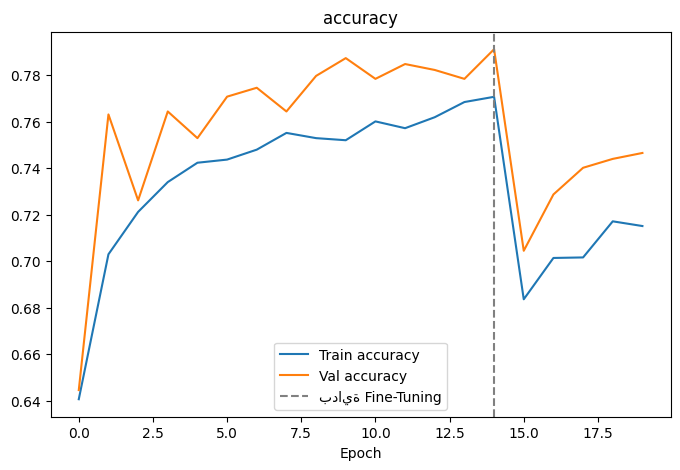

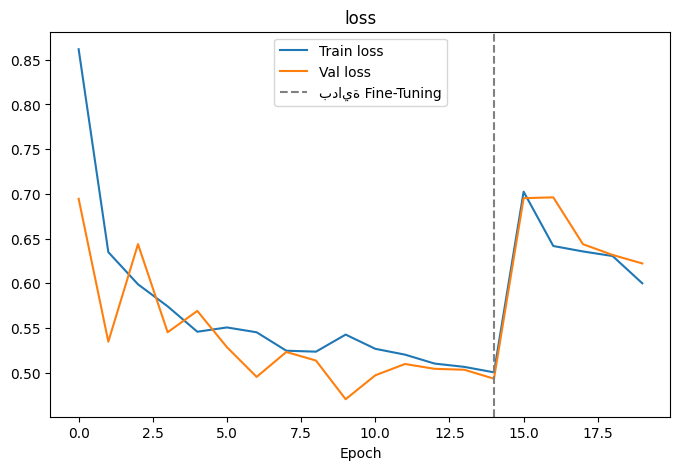

In [13]:
def plot_history(h1, h2, metric="accuracy"):
    vals = h1.history[metric] + h2.history[metric]
    val_vals = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    plt.figure(figsize=(8, 5))
    plt.plot(vals, label=f"Train {metric}")
    plt.plot(val_vals, label=f"Val {metric}")
    plt.axvline(x=len(h1.history[metric]) - 1, color="gray", linestyle="--", label="بداية Fine-Tuning")
    plt.title(metric)
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

plot_history(history1, history2, "accuracy")
plot_history(history1, history2, "loss")

## 10) التقييم النهائي على مجموعة الاختبار (Test Set)

In [14]:
# النموذج مُجمَّع بـ accuracy و auc فقط (بدون Precision/Recall في Keras)
eval_results = model.evaluate(test_gen, return_dict=True)
print(eval_results)
print(f"Test Accuracy : {eval_results['accuracy']:.4f}")
print(f"Test AUC      : {eval_results['auc']:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8077 - auc: 0.9363 - loss: 0.4934
{'accuracy': 0.807692289352417, 'auc': 0.93634432554245, 'loss': 0.49338433146476746}
Test Accuracy : 0.8077
Test AUC      : 0.9363


In [ ]:
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

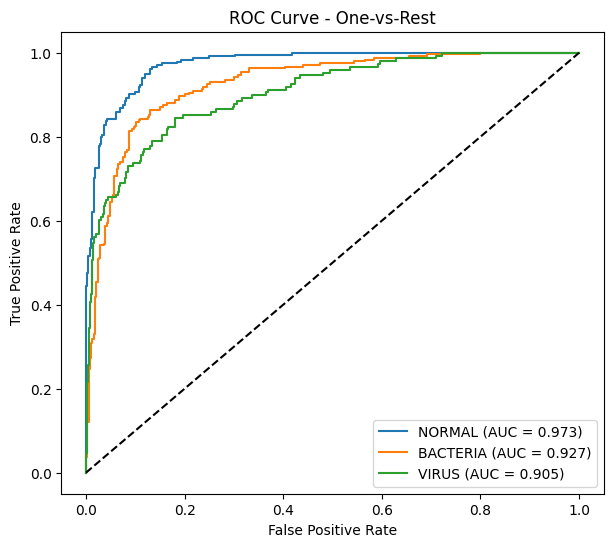

In [17]:
# منحنى ROC-AUC لكل فئة (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure(figsize=(7, 6))
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-vs-Rest")
plt.legend()
plt.show()

## 11) التفسير البصري (Grad-CAM)

يوضح المناطق في الصورة التي اعتمد عليها النموذج لاتخاذ القرار — مهم جدًا لأي بحث طبي يعتمد
على الذكاء الاصطناعي، لأنه يعزز الثقة والقابلية للتفسير (Explainability).

In [ ]:
# إيجاد اسم آخر طبقة Conv (قبل GlobalAveragePooling2D الخاصة بالرأس)
# ملاحظة: في Keras 3 خاصية layer.output_shape أُلغيت؛ نستخدم layer.output.shape بدلاً منها
last_conv_layer_name = None
for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer_name = layer.name
            break
    except AttributeError:
        continue

print("آخر طبقة Conv:", last_conv_layer_name)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


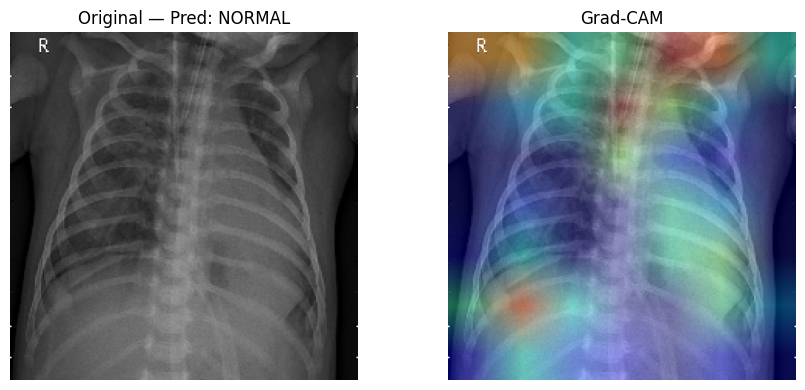

In [19]:
try:
    from keras.utils import load_img, img_to_array
except ImportError:
    from tensorflow.keras.utils import load_img, img_to_array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    conv_layer = model.get_layer(last_conv_layer_name)
    model_output = model.output if not isinstance(model.output, (list, tuple)) else model.output[0]
    grad_model = keras.Model(
        model.inputs,
        [conv_layer.output, model_output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index


def display_gradcam(filepath, model, last_conv_layer_name, img_size=IMG_SIZE):
    img = load_img(filepath, target_size=(img_size, img_size))
    img_array_raw = img_to_array(img)          # [0, 255] -- يدخل للموديل كما هو
    img_array_disp = img_array_raw / 255.0     # [0, 1] -- للعرض البصري فقط
    img_input = np.expand_dims(img_array_raw, axis=0)

    heatmap, pred_class = make_gradcam_heatmap(img_input, model, last_conv_layer_name)

    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]
    jet_heatmap = tf.image.resize(jet_heatmap, (img_size, img_size)).numpy()

    superimposed = jet_heatmap * 0.4 + img_array_disp
    superimposed = np.clip(superimposed, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img_array_disp); axes[0].set_title(f"Original — Pred: {CLASSES[pred_class]}"); axes[0].axis("off")
    axes[1].imshow(superimposed); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# مثال على عينة عشوائية من مجموعة الاختبار
sample_path = test_df["filepath"].sample(1, random_state=SEED).values[0]
display_gradcam(sample_path, model, last_conv_layer_name)

## 12) حفظ النموذج النهائي

In [20]:
model.save("pneumonia_efficientnetv2b0_final.keras")
print("تم حفظ النموذج بنجاح.")

تم حفظ النموذج بنجاح.


---
### ملاحظات للبحث العلمي
- إذا رغبت بمقارنة النموذج مع MobileNetV2 الأصلي، يكفي استبدال `EfficientNetV2B0` بـ `MobileNetV2` في خلية بناء النموذج مع الإبقاء على باقي الخطوات كما هي (لإجراء مقارنة عادلة Apples-to-Apples).
- يفضّل تكرار التجربة بعدة seeds وأخذ متوسط النتائج لضمان الموثوقية الإحصائية.
- بالإمكان أيضًا تجربة نماذج حديثة أخرى مثل `ConvNeXtTiny` أو `EfficientNetV2S` للمقارنة.